In [31]:
%config InlineBackend.figure_format = 'retina'


import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import cumtrapz
from scipy.interpolate import griddata
from matplotlib.gridspec import GridSpec
from matplotlib import colors
import cmasher as cmr
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys

from matplotlib import rcParams

line_width=0.5
capsize=2
mark_edge_color=[0,0,0,0.5]
line_color=[0,0,0,1]
mark_edge_width=0.5
label_fontsize =25
legend_fontsize=20
axis_fontsize=20
ticks_fontsize=legend_fontsize
dist_box = 0.04
labelbox_alpha=0.9
grid_alpha=0.3
size_dots_primary=7*1.3
size_dots_redundant=7*1.

from matplotlib import rcParams
rcParams['font.family']='serif'
rcParams['text.usetex']=True
rcParams['xtick.top']=True
rcParams['xtick.direction']='in'
rcParams['ytick.right']=True
rcParams['ytick.direction']='in'
rcParams['ytick.major.size']=6
rcParams['ytick.minor.size']=3
rcParams['ytick.major.width']=1.2
rcParams['ytick.minor.width']=1.2
rcParams['ytick.minor.visible']=True
rcParams['xtick.major.size']=6
rcParams['xtick.minor.size']=3
rcParams['xtick.major.width']=1.2
rcParams['xtick.minor.width']=1.2
rcParams['xtick.minor.visible']=True
rcParams['lines.linewidth']=1.5
rcParams['lines.markeredgewidth']=mark_edge_width
rcParams['axes.labelsize']=axis_fontsize
rcParams['axes.titlesize']=17
rcParams['xtick.labelsize']=ticks_fontsize
rcParams['ytick.labelsize']=ticks_fontsize
rcParams['legend.fontsize']=legend_fontsize
rcParams['font.size']=label_fontsize





In [4]:
G = 6.67430e-8  # Gravitational constant in cm^3 g^-1 s^-2
c = 2.99792458e10  # Speed of light in cm/s
Msol = 1.98847e33  # Solar mass in grams
k_B = 1.380649e-16  # Boltzmann constant in erg/K
sigma_sb = 5.670374419e-5  # Stefan-Boltzmann constant in erg cm^-2 s^-1 K^-4
kappa_es = 0.34  # Opacity in cm^2/g (for electron scattering)
m_H = 1.6726219e-24  # Hydrogen atom mass in grams
a_radiation = 7.5657e-15  # Radiation constant in erg cm^-3 K^-4
kappa_0 = 0.64 * 1e23  # cm^2/g, opacity at T=10^4 K


In [5]:
def rg(m):
    return G * m * Msol / c**2  # Schwarzschild radius in cm

def Omega_K(r, m):
    """
    Compute the Keplerian angular velocity Omega_K for a given radius r and black hole mass m.

    Parameters:
    r : float
        Radius in units of 2 r_g (where r_g = GM/c^2)
    m : float
        Black hole mass in solar masses

    Returns:
    Omega_K : float
        Keplerian angular velocity in s^-1
    """
    r_g = rg(m)  # Schwarzschild radius in cm
    Omega_K = np.sqrt(G * m * Msol  / (r * r_g)**3)  # in s^-1
    return Omega_K


def kappa_ff(Sigma, H, T):
    """
    Compute the free-free opacity kappa_ff for a given surface density Sigma, temperature T, and other parameters.

    Parameters:
    Sigma : float
        Surface density in g/cm^2
    H : float
        Scale height in cm
    T : float
        Temperature in Kelvin

    Returns:
    kappa_ff : float
        Free-free opacity in cm^2/g
    """
    kappa_ff = kappa_0 * Sigma * np.power(T,-3.5) / (2* H)
    return kappa_ff

def kappa(kappa_ff):
    """
    Compute the opacity kappa for a given surface density Sigma, temperature T, and other parameters.

    Parameters:
    Sigma : float
        Surface density in g/cm^2
    T : float
        Temperature in Kelvin
    cs : float
        Sound speed in cm/s
    Omega : float
        Angular velocity in s^-1

    Returns:
    kappa : float
        Opacity in cm^2/g
    """
    kappa = kappa_es + kappa_ff
    return kappa

def Prad(T):
    """
    Compute the radiation pressure P_rad for a given temperature T.

    Parameters:
    T : float
        Temperature in Kelvin

    Returns:
    P_rad : float
        Radiation pressure in dyne/cm^2
    """
    P_rad = a_radiation * T**4 / 3  # Radiation pressure in dyne/cm^2
    return P_rad

def Pgas(Sigma,T,H):
    """
    Compute the gas pressure P_gas for a given surface density Sigma, temperature T, and scale height H.

    Parameters:
    Sigma : float
        Surface density in g/cm^2
    T : float
        Temperature in Kelvin
    H : float
        Scale height in cm

    Returns:
    P_gas : float
        Gas pressure in dyne/cm^2
    """
    P_gas = Sigma * k_B * T / (m_H * H)  # Gas pressure in dyne/cm^2
    return P_gas

def Q_plus(alpha,P, Omega, H):
    """
    Compute the viscous heating term Q+ for a given temperature T, surface density Sigma, and viscosity parameter alpha.

    Parameters:
    alpha : float
        Viscosity parameter (dimensionless) 
    P : float
        Pressure in dyne/cm^2
    Omega : float
        Angular velocity in s^-1
    H : float
        Scale height in cm

    Returns:
    Q_plus : float
        Viscous heating term Q+ in erg/cm^3/s
    """
    Q_plus = 3 * H * alpha * P * Omega  # Viscous heating term in erg/cm^3/s       
    return Q_plus

def Q_minus(T,kappa,Sigma):
    """
    Compute the viscous cooling term Q- for a given temperature T, opacity kappa, and surface density Sigma.

    Parameters:
    T : float
        Temperature in Kelvin
    kappa : float
        Opacity in cm^2/g
    Sigma : float
        Surface density in g/cm^2

    Returns:
    Q_minus : float
        Viscous cooling term Q- in erg/cm^3/s
    """
    
    Q_minus = (8 * a_radiation * c * T**4) / (3/2 * kappa * Sigma)  # Radiative cooling term in erg/cm^3/s
    return Q_minus

def H_fun(P, Sigma, Omega):
    """
    Compute the scale height H for a given pressure P, surface density Sigma, and angular velocity Omega.

    Parameters:
    P : float
        Pressure in dyne/cm^2
    Sigma : float
        Surface density in g/cm^2
    Omega : float
        Angular velocity in s^-1

    Returns:
    H : float
        Scale height in cm
    """
    
    H = 2 * P / (Omega**2 * Sigma)  # Scale height in cm

    return H

def tot_pressure(T,Sigma,H):
    """
    Compute the total pressure P_total for a given temperature T, surface density Sigma, and scale height H.

    Parameters:
    T : float
        Temperature in Kelvin
    Sigma : float
        Surface density in g/cm^2
    H : float
        Scale height in cm

    Returns:
    P_total : float
        Total pressure in dyne/cm^2
    """
    
    P_rad = Prad(T)
    P_gas = Pgas(Sigma, T, H)
    P_total = P_rad + P_gas  # Total pressure in dyne/cm^2
    return P_total

In [6]:
from scipy.optimize import fsolve

def solve_P(Sigma, T, Omega, R, m, H0=1e-2, T0=1e5):
    """
    Solve for total pressure P given P = Prad(T) + Pgas(Sigma, T, H(P)),
    where H is implicitly a function of P via H_fun.

    Parameters:
    Sigma : float
        Surface density in g/cm^2
    T : float
        Temperature in Kelvin
    Omega : float
        Angular velocity in s^-1

    Returns:
    P : float
        Total pressure in dyne/cm^2
    """

    
    # Initial guess for P
    Sigma0 = 1e1
    H0 = H0 * R * rg(m)  # Initial guess for scale height in cm
    T0 = 1e5
    def equation(P, Sigma, T, Omega):
        return (2*k_B / m_H) * Sigma**2 * T * Omega**2 / (4 * P) + a_radiation * T**4 / 3 - P

    P_initial = tot_pressure(T0, Sigma0, H0)
    P_solution = fsolve(equation, P_initial, args=(Sigma, T, Omega))

    return P_solution[0]


In [7]:
# Inner, middle and outer solution for SS disk




def T_inner(alpha, m, R):
    """
    Compute the central temperature in inner region Tc [K] as a function of:
    alpha : viscosity parameter (dimensionless)
    m     : black hole mass [in solar masses]
    R : dimensionless radius r/r_g
    """
    R= R/2
    return 4.9e7 * (alpha * m)**(-1/4) * R**(-3/8)


def T_outer(alpha, m, mdot, R):
    """
    Compute the outer temperature in the disk region To [K] as a function of:
    alpha : viscosity parameter (dimensionless)
    m     : black hole mass [in solar masses]
    mdot  : mass accretion rate [in solar masses per year]
    R     : dimensionless radius r/r_g
    """
    R = R / 2
    
    return 6.9e7 * alpha**(-1/5) * m**(-1/5) * mdot**(3/10) * R**(-3/4) * f_r(R,m)**(3/10)

def mdot_outer(alpha, m, Sigma, R):
    """
    Compute the outer surface density in the disk region Sigma_o [g/cm^2] as a function of:
    alpha : viscosity parameter (dimensionless)
    m     : black hole mass [in solar masses]
    mdot  : mass accretion rate 
    R     : dimensionless radius r/r_g
    """
    R = R / 2
    mdot = np.power(Sigma/1.4e5, 10/7) * np.power(m,-2/7)* np.power(alpha, 8/7) * np.power(R,15/14) * 1 / f_r(R,m)
    return mdot

def f_r(R, m):
    """
    Compute the function f(R, m) for the outer disk region.
    
    Parameters:
    R : float
        Dimensionless radius r/r_g
    m : float
        Black hole mass in solar masses
    
    Returns:
    f_val : float
        Value of the function f(R, m)
    """
    r = R   # Convert dimensionless radius to physical radius in cm
    
    return 1 - np.sqrt(3 / (r))

def mdot_middle(alpha, m, Sigma, R):
    """
    Compute the mass accretion rate mdot in the middle region of the disk.
    
    Parameters: 
    alpha : float
        Viscosity parameter (dimensionless)
    m : float
        Black hole mass in solar masses
    sigmas : array-like
        Surface density values in g/cm^2
    R : float
        Dimensionless radius r/r_g  
    Returns:
    mdots : array-like
        Mass accretion rates 
    """
    R = R / 2  
    Sigma = np.asarray(Sigma)  # Ensure sigmas is an array
    mdots = np.power(Sigma/4.3e4, 5/3) * np.power(alpha,4/3) * np.power(m, -1/3) * np.power(f_r(R, m), -1)
    return mdots

def T_middle(alpha, m, mdot, R):
    """
    Compute the temperature in the middle region of the disk.
    
    Parameters:
    alpha : float
        Viscosity parameter (dimensionless)
    m : float
        Black hole mass in solar masses
    mdot : array-like
        Mass accretion rates 
    R : float
        Dimensionless radius r/r_g
    Returns:
    Ts : array-like
        Temperatures in Kelvin
    """
    R = R / 2  
    mdot = np.asarray(mdot)  # Ensure mdots is an array
    Ts = 2.2e8 * np.power(alpha, -1/5) * np.power(m, -1/5) * np.power(mdot, 2/5) * np.power(R, -9/10) * np.power(f_r(R, m),2/5)
    return Ts

def sig_eq_mid(T, R, m, alpha):
    """
    Calculate the equilibrium surface density Sigma_eq for the middle region of the disk.
    
    Parameters:
    T : float
        Temperature in Kelvin
    R : float
        Dimensionless radius r/r_g
    m : float
        Black hole mass in solar masses
    alpha : float
        Viscosity parameter (dimensionless)
        
    Returns:
    Sigma_eq : float
        Equilibrium surface density in g/cm^2
    """
    foo = 64 * m_H * sigma_sb * T**3
    bar = 9 * kappa_es * k_B * alpha * Omega_K(R, m)
    
    return np.sqrt(foo / bar)

def T_eq_in(R,m,alpha):
    """
    Calculate the equilibrium temperature in the inner region of the disk.
    
    Parameters:
    R : float
        Dimensionless radius r/r_g
    m : float
        Black hole mass in solar masses
    alpha : float
        Viscosity parameter (dimensionless) 
    Returns:
    T_eq : float
        Equilibrium temperature in Kelvin
    """
    foo = 576 * Omega_K(R, m) * sigma_sb
    bar = 54 * alpha * kappa_es * a_radiation**2
    return np.power(foo / bar, 1/4)


In [8]:
## PRAMETERS TO CALCULATE EVERYTHING    
m = 10
R = 10
alpha = 0.1
sigmas = np.logspace(2,6,100)
Ts = np.logspace(4, 8, 100)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


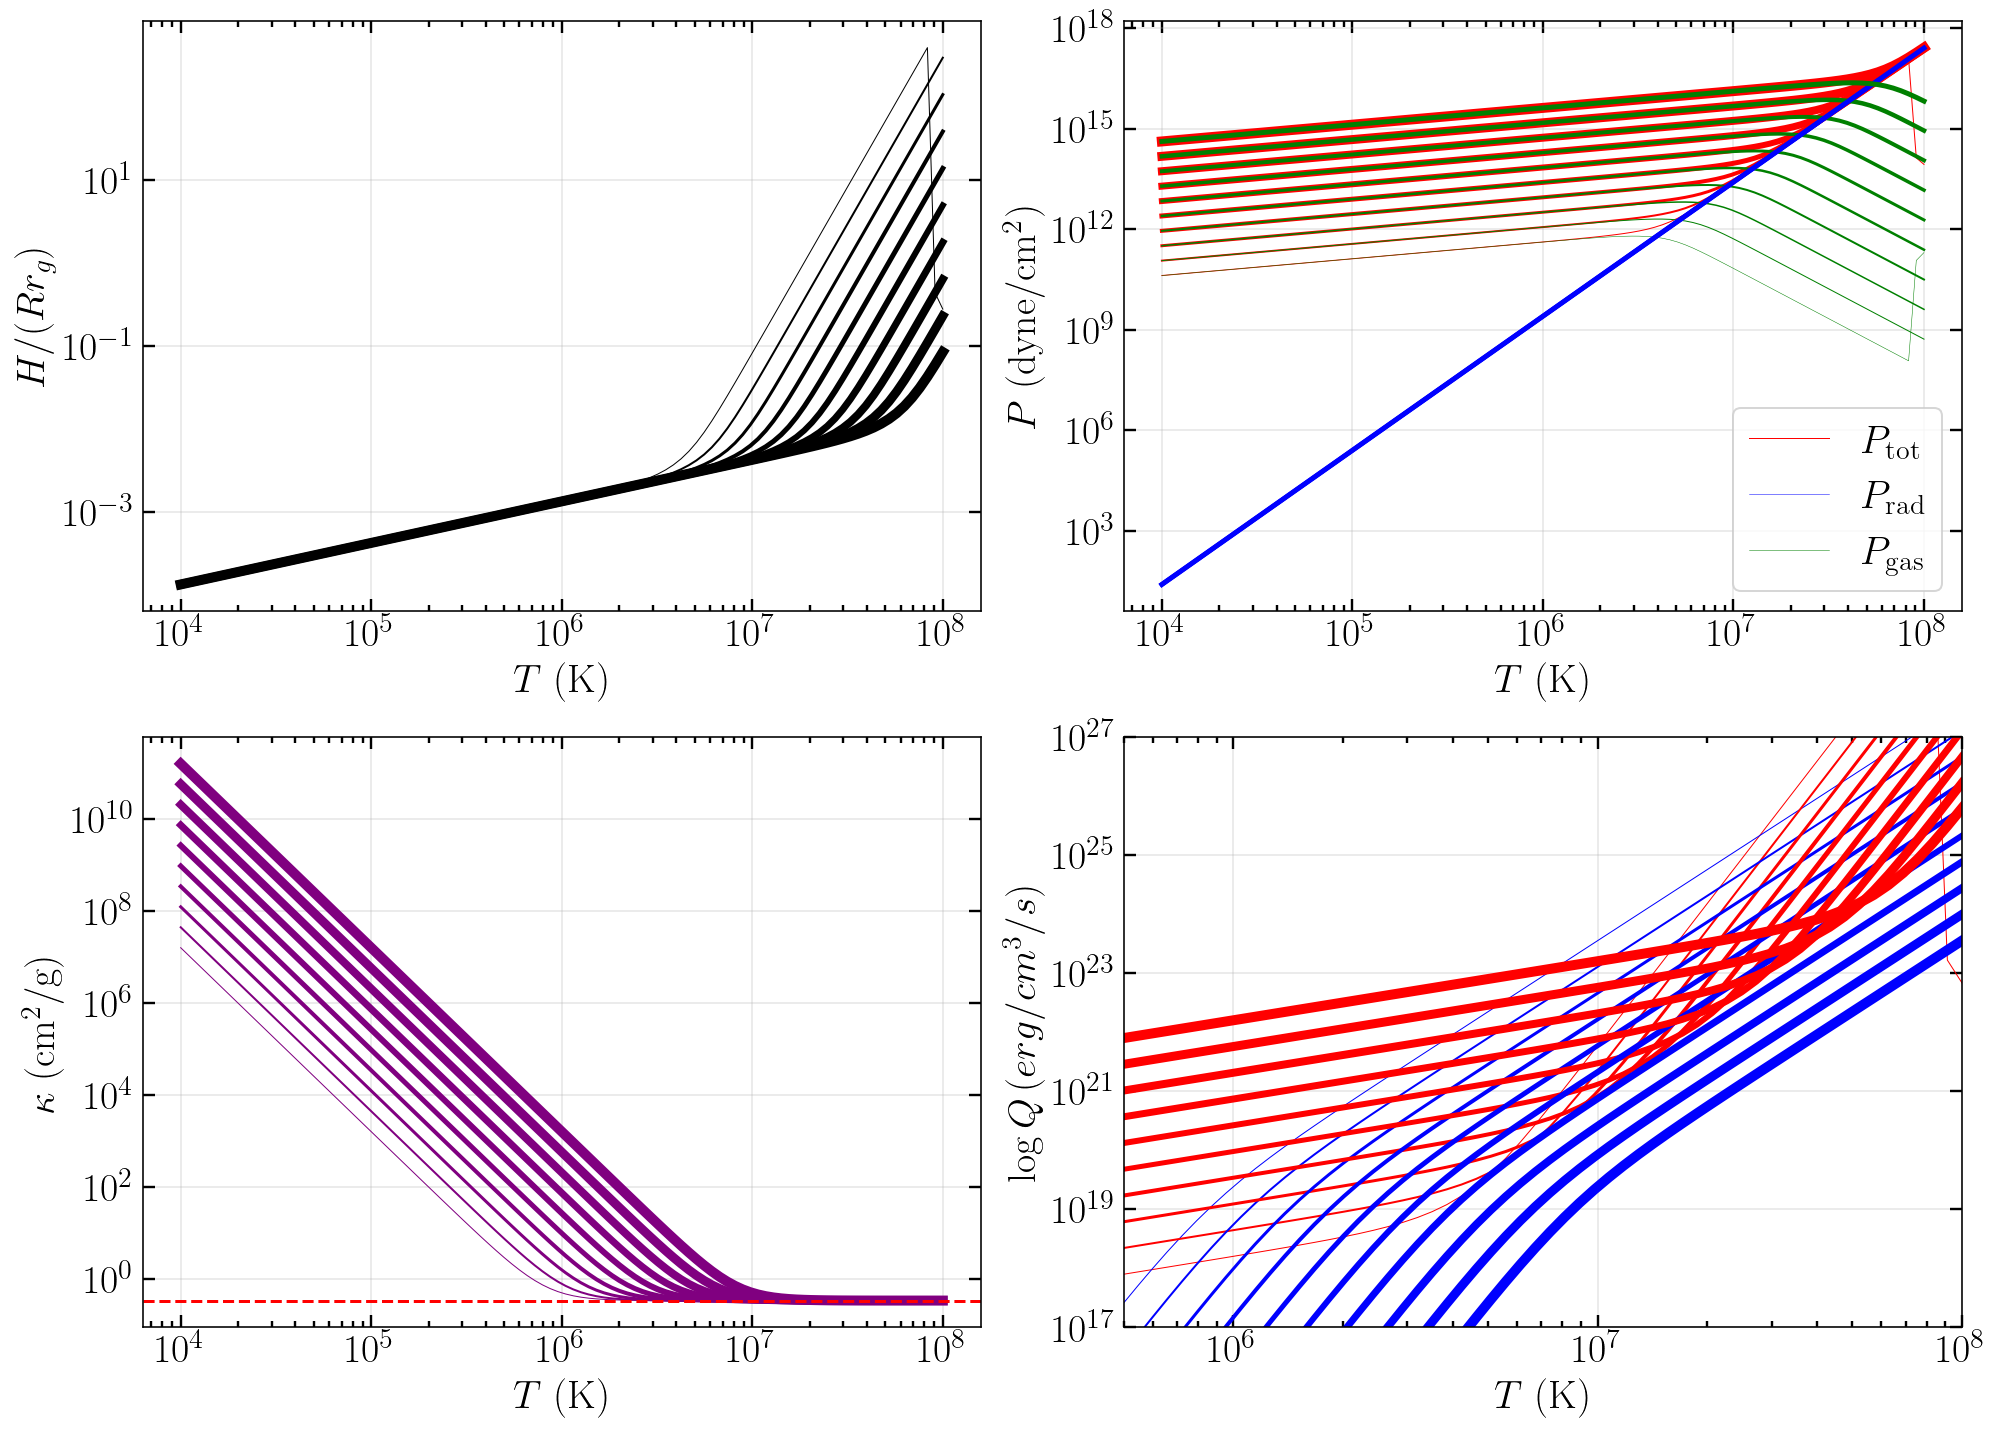

In [9]:
Sig_lines = np.logspace(2, 6, 10)  # Surface density values in g/cm^2 to plot several solutions

fig, axs = plt.subplots(2, 2, figsize=(14, 10))


for i, s in enumerate(Sig_lines):
    # Calculate Omega_K for the given radius R and mass m
    Omega = Omega_K(R, m)
    
    # Calculate the total pressure P for each temperature T
    Ps = np.array([solve_P(s, T, Omega, R, m) for T in Ts])
    # Calculate the scale height H for each temperature T (using Ps)
    Hs = H_fun(Ps, s, Omega)
    axs[0, 0].loglog(Ts, Hs/(R*rg(m)), color='black', lw=(i+1)/2)

    Pr = Prad(Ts)
    Pg = Pgas(s, Ts, Hs)
    axs[0, 1].loglog(Ts, Ps, color='red', lw=(i+1)/2, label=r'$P_{\rm tot}$' if i == 0 else None)
    axs[0, 1].loglog(Ts, Pr, color='blue', lw=(i+1)/4, label=r'$P_{\rm rad}$' if i == 0 else None)
    axs[0, 1].loglog(Ts, Pg, color='green', lw=(i+1)/4, label=r'$P_{\rm gas}$' if i == 0 else None)
    # axs[0, 1].loglog(Ts, Pr + Pg, color='k', lw=i/4, label=r'$P_{\rm tot}$')
    # Calculate the free-free opacity kappa_ff
    kap = kappa(kappa_ff(s, Hs, Ts))
    axs[1, 0].loglog(Ts, kap, color='purple', lw=(i+1)/2, label=r'$\kappa$')

    # Calculate the heating and cooling rates
    Qp = Q_plus(alpha, Ps, Omega, Hs)
    Qm = Q_minus(Ts, kap, s)
    axs[1, 1].loglog(Ts, Qp, color='red', lw=(i+1)/2)
    axs[1, 1].loglog(Ts, Qm, color='blue', lw=(i+1)/2)


# Top left: H/(R*rg(m))
axs[0, 0].set_xlabel(r'$T$ (K)')
axs[0, 0].set_ylabel(r'$H/(R r_g)$')
axs[0, 0].grid(alpha=0.3)

# Top right: Pressure

axs[0, 1].set_xlabel(r'$T$ (K)')
axs[0, 1].set_ylabel(r'$P$ (dyne/cm$^2$)')
axs[0, 1].grid(alpha=0.3)
axs[0, 1].legend()

# Bottom left: Opacity
axs[1, 0].axhline(kappa_es, color='red', ls='--', label='Electron scattering')
axs[1, 0].set_xlabel(r'$T$ (K)')
axs[1, 0].set_ylabel(r'$\kappa$ (cm$^2$/g)')
axs[1, 0].grid(alpha=0.3)

# Bottom right: Heating and cooling rates

axs[1, 1].set_xlabel(r'$T$ (K)')
axs[1, 1].set_ylabel(r'$\log Q\, (erg/cm^3/s)$')
axs[1, 1].grid(alpha=0.3)
axs[1, 1].set_ylim(1e17,1e27)
axs[1, 1].set_xlim(5e5,1e8)

plt.tight_layout()
# plt.loglog(Ts, Prad(Ts), color='orange', lw=2, label=r'$P_{\rm rad}$')
# plt.loglog(Ts, Pgas(s0, Ts, Hs), color='green', lw=2, label=r'$P_{\rm gas}$')

# plt.axhline(kappa_es, color='red', ls='--', label='Electron scattering opacity')
plt
plt.show()

In [10]:
def heating_cooling(Ts, Sigma, R, m, alpha=0.1):
    Om = Omega_K(R, m)


    # Ensure Ts and Sigma are broadcastable to the same shape
    Ts = np.asarray(Ts)
    Sigma = np.asarray(Sigma)
    # Broadcast Ts and Sigma to a common shape
    Ts_b, Sigma_b = np.broadcast_arrays(Ts, Sigma)
    # Flatten for iteration
    Ts_flat = Ts_b.ravel()
    Sigma_flat = Sigma_b.ravel()
    # Solve for P for each (Sigma, T) pair
    P_flat = np.array([solve_P(s, t, Om, R, m) for s, t in zip(Sigma_flat, Ts_flat)])
    # Reshape to broadcasted shape
    P = P_flat.reshape(Ts_b.shape)

    Hs = H_fun(P, Sigma, Om)
    
    Pr = Prad(Ts)
    Pg = Pgas(Sigma, Ts, Hs)
    Ps = Pr + Pg
    kappa_values = kappa(kappa_ff(Sigma, Hs, Ts))
    Qp = Q_plus(alpha, Ps, Om, Hs)
    Qm = Q_minus(Ts, kappa_values, Sigma)
    return Qp, Qm

In [11]:
from scipy.optimize import brentq

def find_all_roots_robust(func, x_min, x_max, num_brackets=1000, *args):
    """
    Find all roots of a function in a given interval by subdividing 
    the interval and using bracket methods.
    
    Parameters:
    func : callable
        Function to find roots for
    x_min, x_max : float
        Search interval
    num_brackets : int
        Number of sub-intervals to check
    *args : additional arguments for func
    
    Returns:
    roots : list
        List of all roots found
    """
    roots = []
    x_array = np.logspace(np.log10(x_min), np.log10(x_max), num_brackets)
    
    for i in range(len(x_array) - 1):
        x1, x2 = x_array[i], x_array[i + 1]
        
        try:
            # Evaluate function at bracket endpoints
            f1 = func(x1, *args)
            f2 = func(x2, *args)
            
            # Check if there's a sign change (root exists)
            if f1 * f2 < 0:
                root = brentq(func, x1, x2, args=args)
                    
                # Check if this root is new (not too close to existing ones)
                is_new = True
                for existing_root in roots:
                    if abs(root - existing_root) / root < 1e-6:  # Relative tolerance
                        is_new = False
                        break
                
                if is_new:
                    roots.append(root)
                    
        except (ValueError, RuntimeError):
            # Skip brackets where root finding fails
            continue
    
    return sorted(roots)

def find_equilibrium_temperatures(Sigma, R, m, alpha=0.1, T_min=1e5, T_max=1e8):
    """
    Find all equilibrium temperatures where Q+ = Q- for a given Sigma.
    
    Parameters:
    Sigma : float
        Surface density
    R, m : float
        Radius and mass parameters
    alpha : float
        Viscosity parameter
        
    Returns:
    T_solutions : list
        All equilibrium temperatures found
    """
    def equilibrium_function(T, Sigma, R, m, alpha):
        qp, qm = heating_cooling(T, Sigma, R, m, alpha)
        return (qp) - (qm)
    
    # Search for roots in temperature range
    roots = find_all_roots_robust(equilibrium_function, T_min, T_max, 100, 
                                 Sigma, R, m, alpha)
    
    return roots

Testing with Sigma = 1.0e+02
Found 3 equilibrium temperatures: [595836.9770834768, 27815031.019126378, 83603496.53635304]


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


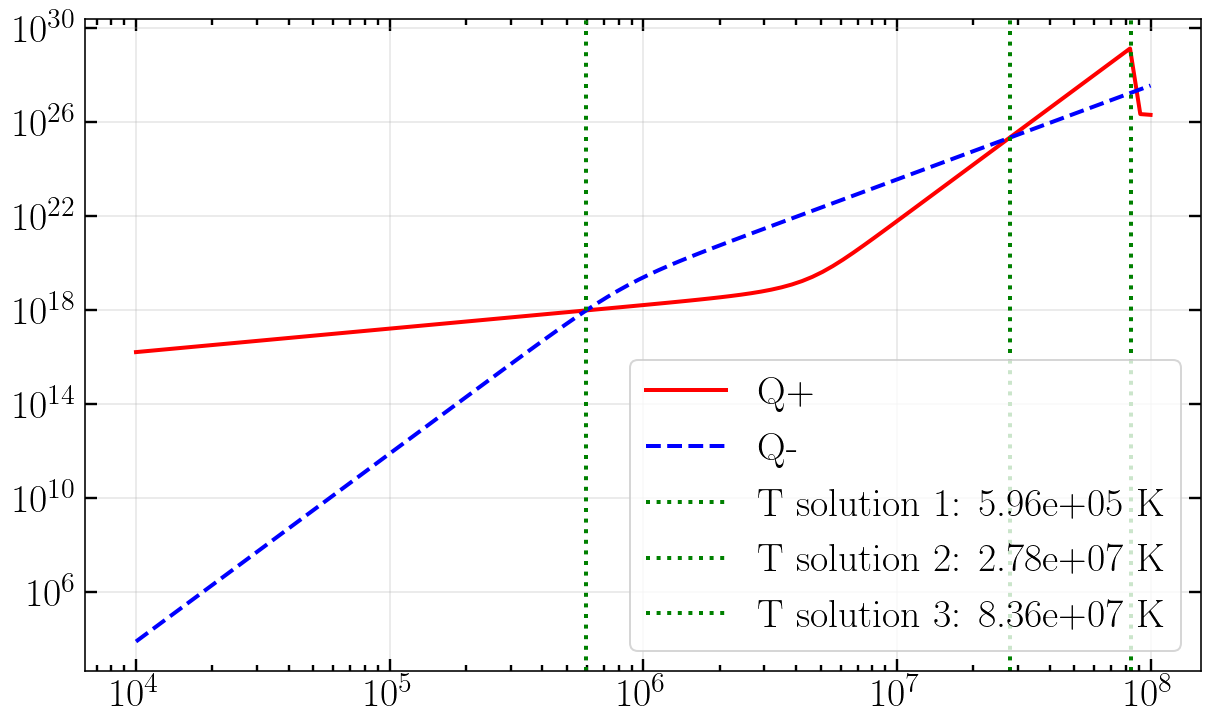

In [12]:
def find_sigma_T_curves(sigmas, R, m, alpha=0.1):
    """
    Find both temperature solutions for each Sigma value.
    
    Parameters:
    sigmas : array
        Array of surface density values
    R, m : float
        Radius and mass parameters
    alpha : float
        Viscosity parameter
        
    Returns:
    T_solutions_1, T_solutions_2 : arrays
        Arrays of first and second temperature solutions
    """
    T_solutions_1 = []
    T_solutions_2 = []
    
    for i, sigma in enumerate(sigmas):
        if i % 10 == 0:  # Progress indicator
            print(f"Processing Sigma {i+1}/{len(sigmas)}: {sigma:.2e}")
            
        roots = find_equilibrium_temperatures(sigma, R, m, alpha)
        
        if len(roots) >= 1:
            T_solutions_1.append(roots[0])
        else:
            T_solutions_1.append(np.nan)
            
        if len(roots) >= 2:
            T_solutions_2.append(roots[1])
        else:
            T_solutions_2.append(np.nan)
    
    return np.array(T_solutions_1), np.array(T_solutions_2)

# Test the new method


# Test with a single Sigma first
test_sigma = 1e2
print(f"Testing with Sigma = {test_sigma:.1e}")
test_roots = find_equilibrium_temperatures(test_sigma, R, m, alpha)
print(f"Found {len(test_roots)} equilibrium temperatures: {test_roots}")

# Plot the Q+ and Q- curves to visualize the intersections
qp, qm = heating_cooling(Ts, test_sigma, R, m, alpha)

plt.figure(figsize=(10, 6))
plt.loglog(Ts, qp, color='red', label='Q+', linewidth=2)
plt.loglog(Ts, qm, color='blue', label='Q-', linewidth=2, linestyle='--')

# Mark the found roots
for i, root in enumerate(test_roots):
    plt.axvline(root, color='green', linestyle=':', linewidth=2, 
                label=f'T solution {i+1}: {root:.2e} K')

# plt.xlabel('Temperature (K)')
# plt.ylabel('Q (erg/cm³/s)')
# plt.title(f'Q+ and Q- curves for Σ = {test_sigma:.1e} g/cm²')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:


T_solutions_1, T_solutions_2 = find_sigma_T_curves(sigmas, R, m, alpha)



Processing Sigma 1/100: 1.00e+02
Processing Sigma 11/100: 2.54e+02
Processing Sigma 21/100: 6.43e+02
Processing Sigma 31/100: 1.63e+03
Processing Sigma 41/100: 4.13e+03
Processing Sigma 51/100: 1.05e+04
Processing Sigma 61/100: 2.66e+04
Processing Sigma 71/100: 6.73e+04
Processing Sigma 81/100: 1.71e+05
Processing Sigma 91/100: 4.33e+05


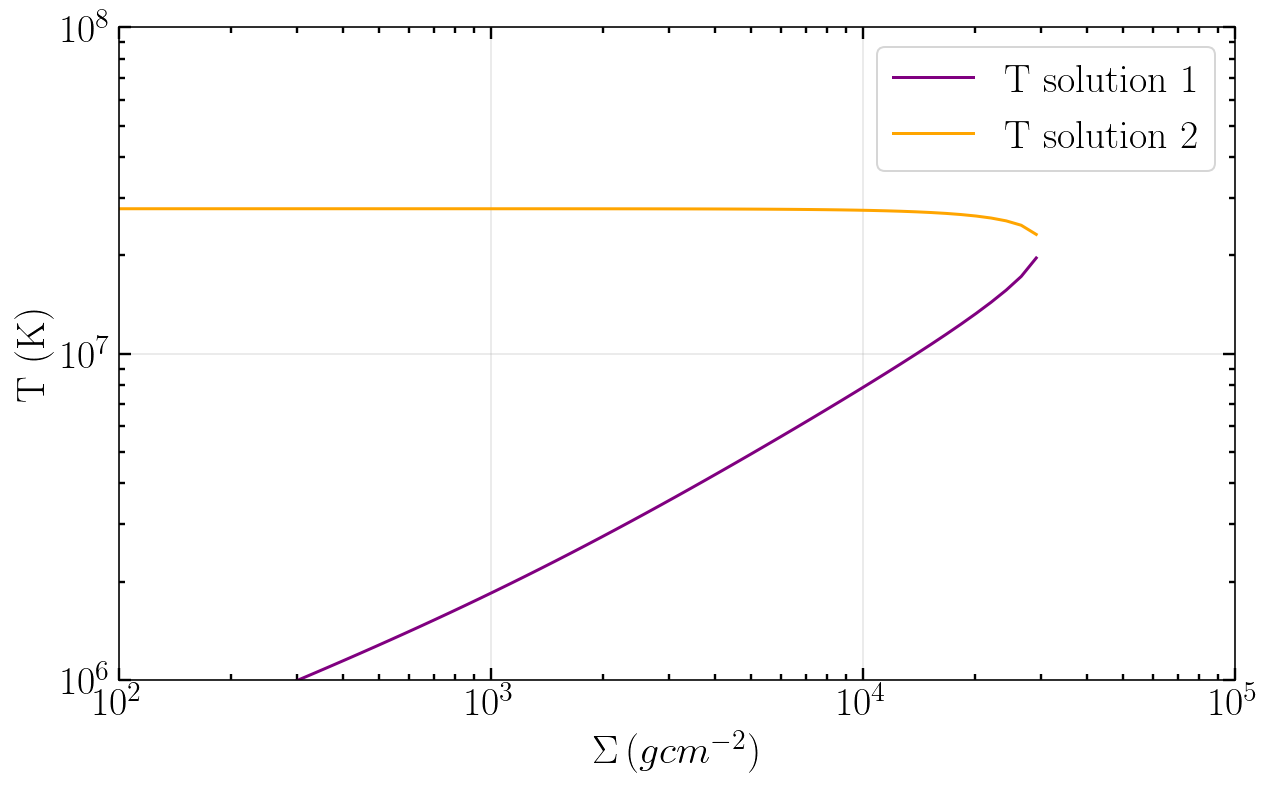

In [14]:

plt.figure(figsize=(10, 6))

# Plot T_solutions_1 and T_solutions_2 separately for each sigma
plt.plot(sigmas, T_solutions_1, color='purple', label='T solution 1')
plt.plot(sigmas, T_solutions_2, color='orange', label='T solution 2')

plt.ylabel(r'T (K)')
plt.xlabel(r'$\Sigma\, (g cm^{-2})$')

plt.xscale('log')
plt.yscale('log')

plt.ylim(1e6,1e8)
plt.xlim(1e2,1e5)

plt.yscale('log')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

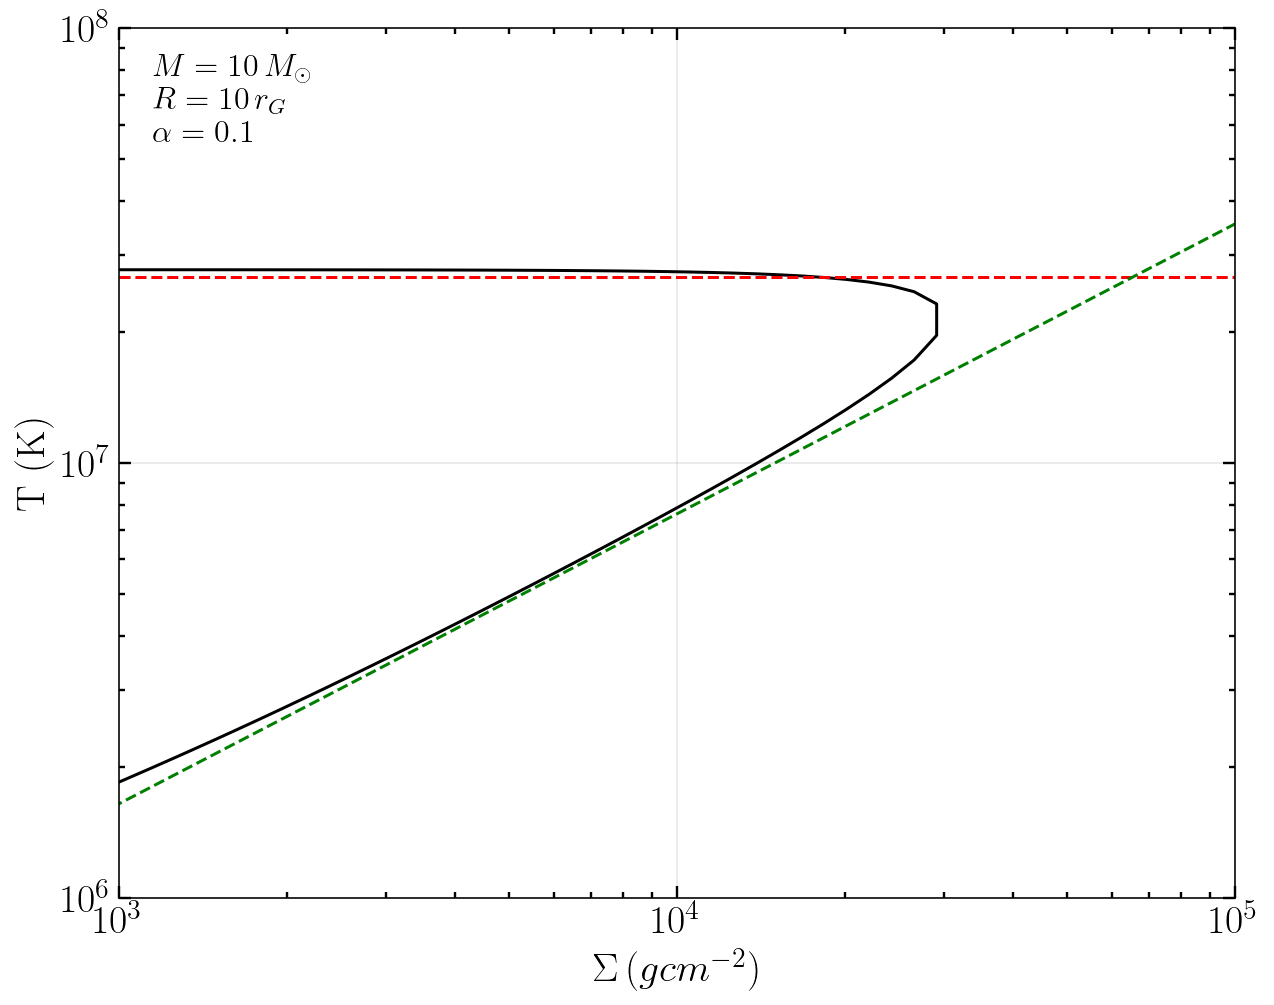

In [15]:
sig_min = 1e3
sig_max = 1e5
sig_an = np.linspace(sig_min,sig_max,100)

sigma_all = np.concatenate([sigmas, sigmas[::-1]])
T_all     = np.concatenate([T_solutions_1,T_solutions_2[::-1]])




mask = ~np.isnan(sigma_all) & ~np.isnan(T_all)
sigma_all = sigma_all[mask]
T_all = T_all[mask]

sigmas_middle = sig_eq_mid(Ts, R, m, alpha)

plt.figure(figsize=(10, 8))

plt.plot(sigma_all, T_all, color='black')


plt.ylabel(r'T (K)')
plt.xlabel(r'$\Sigma\, (g cm^{-2})$')

plt.xscale('log')
plt.yscale('log')

plt.ylim(1e6,1e8)
plt.xlim(sig_min, sig_max)

plt.yscale('log')
plt.xscale('log')
plt.grid(True, alpha=0.3)

plt.axhline(T_inner(alpha, m, R), color='red', linestyle='--')
plt.loglog(sigmas_middle,Ts, color='green', linestyle='--', label='T middle solution')

plt.text(
    0.03, 0.97,
    f"$M={m}\,M_\odot$\n$R={R}\,r_G$\n$\\alpha={alpha}$",
    transform=plt.gca().transAxes,
    fontsize=16,
    verticalalignment='top',
)
# plt.savefig('sigma_T_solutions.pdf',bbox_inches='tight')
plt.show()

In [16]:
# nastier but easier

def Tfun(Sigma, Ts, alpha,R,m):
    Om = Omega_K(R, m)
    # Ensure Ts and Sigma are broadcastable to the same shape
    Ts = np.asarray(Ts)
    Sigma = np.asarray(Sigma)
    # Broadcast Ts and Sigma to a common shape
    Ts_b, Sigma_b = np.broadcast_arrays(Ts, Sigma)
    # Flatten for iteration
    Ts_flat = Ts_b.ravel()
    Sigma_flat = Sigma_b.ravel()
    # Solve for P for each (Sigma, T) pair
    P_flat = np.array([solve_P(s, t, Om, R, m) for s, t in zip(Sigma_flat, Ts_flat)])
    # Reshape to broadcasted shape
    P = P_flat.reshape(Ts_b.shape)
    pg = Pgas(Sigma, Ts, H_fun(P, Sigma, Om))
    Pr = Prad(Ts)
    Ps = Pr + pg
    Hs = H_fun(Ps, Sigma, Om)
    kappa_values = kappa(kappa_ff(Sigma, Hs, Ts))
    fun = 32 * a_radiation * c * Ts**4 - 18 * kappa_values * alpha * Sigma * Om * Ps * Hs
    return fun


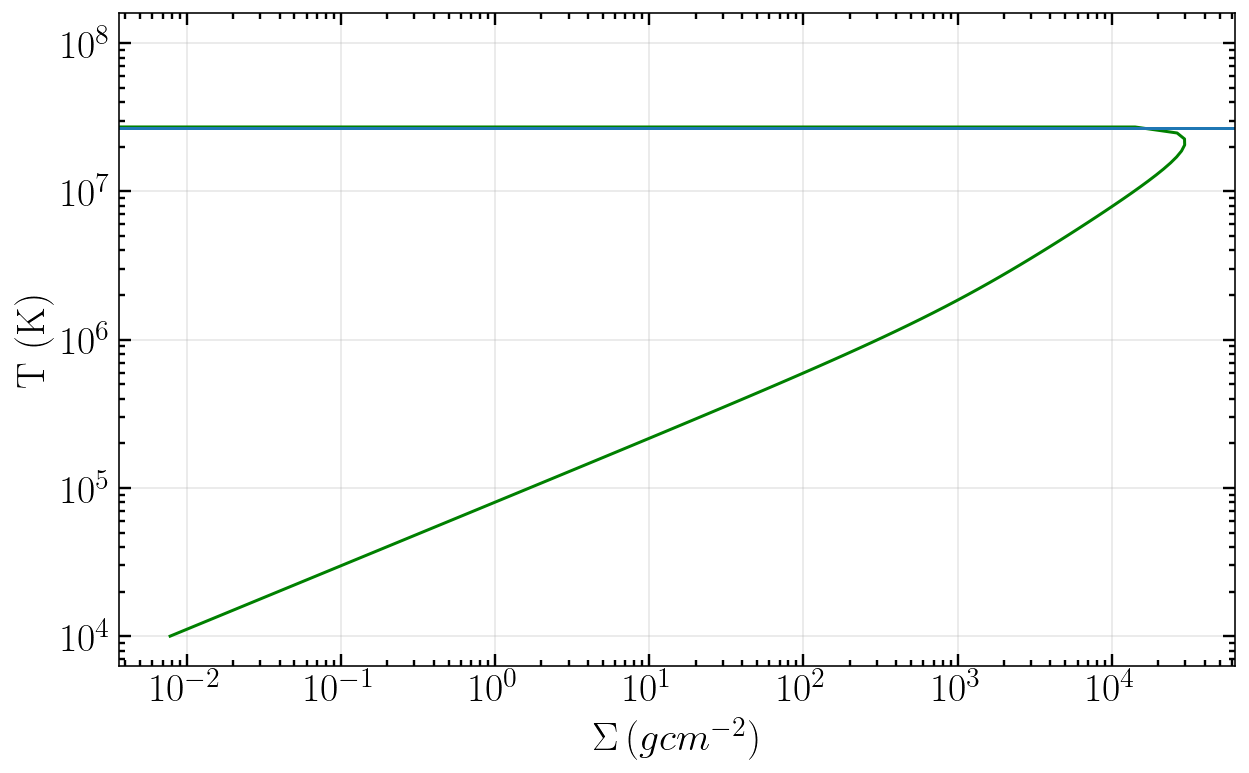

In [17]:

Sigma0 = 1e3


Om = Omega_K(R, m)


sols = []
for i, T in enumerate(Ts):
    solution = fsolve(Tfun, Sigma0, args=(T, alpha, R, m))
    sols.append(solution[0])
    
plt.figure(figsize=(10, 6)) 
plt.loglog(sols,Ts, color='green', label='T solution 1')
plt.axhline(T_inner(alpha, m, R)) 

plt.xlabel(r'$\Sigma\, (g cm^{-2})$')
plt.ylabel(r'T (K)')
plt.grid(True, alpha=0.3)
# plt.xlim(1e2, 1e5)
# plt.ylim(1e6,1e8)
plt.show()

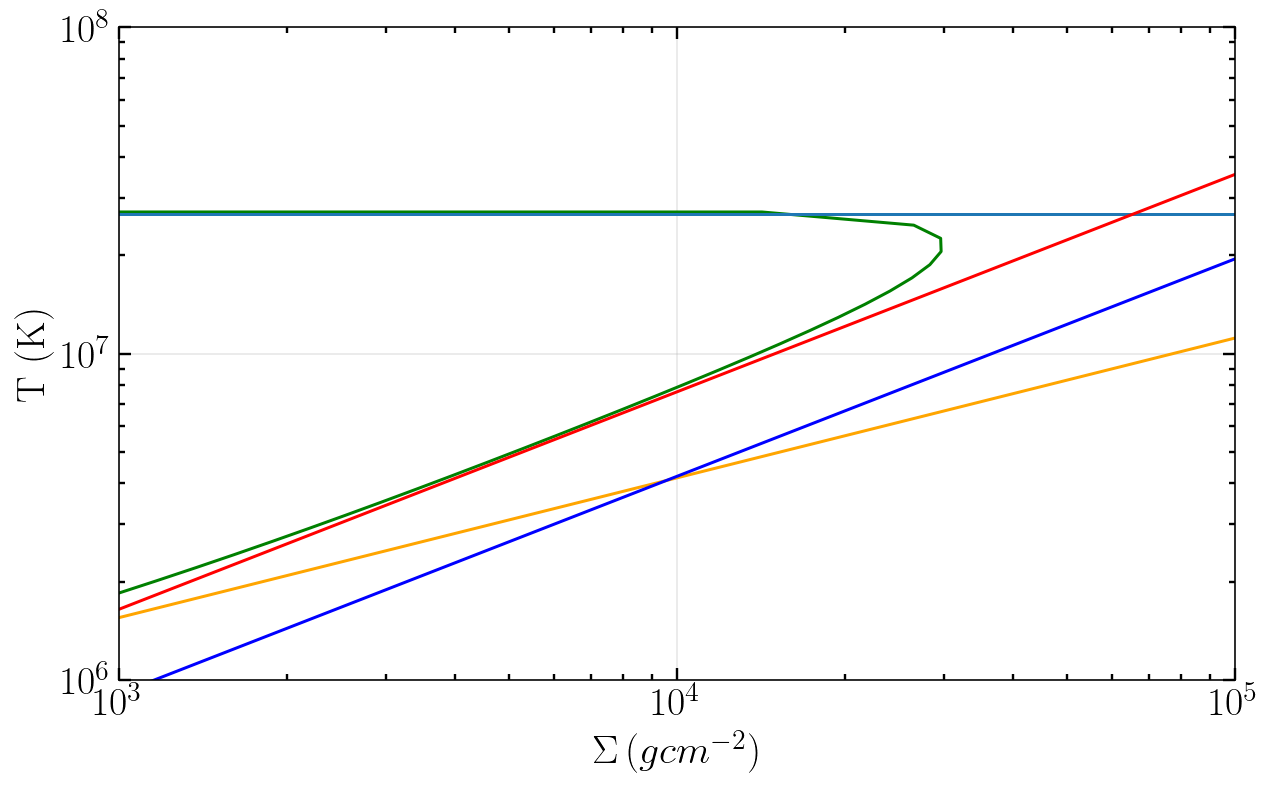

In [18]:

sigmas_test = np.linspace(1e3, 1e5, 100)


mdots_out = mdot_outer(alpha, m, sigmas_test, R)
T_out = T_outer(alpha, m, mdots_out, R)

mdots_mid = mdot_middle(alpha, m, sigmas_test, R)
T_mid = T_middle(alpha, m, mdots_mid, R)

plt.figure(figsize=(10, 6))
plt.loglog(sigmas_test, T_out, color='orange', label='T outer solution')
plt.loglog(sigmas_test, T_mid, color='blue', label='T middle solution')
plt.loglog(sols,Ts, color='green', label='T solution 1')
plt.axhline(T_inner(alpha, m, R)) 
plt.loglog(sig_eq_mid(Ts, R, m, alpha),Ts, color='red', label='T solution 2')

plt.xlabel(r'$\Sigma\, (g cm^{-2})$')
plt.ylabel(r'T (K)')
plt.grid(True, alpha=0.3)
plt.xlim(1e3, 1e5)
plt.ylim(1e6,1e8)
plt.show()

In [19]:
def T_eq_in(R,m,alpha):
    """
    Calculate the equilibrium temperature in the inner region of the disk.
    
    Parameters:
    R : float
        Dimensionless radius r/r_g
    m : float
        Black hole mass in solar masses
    alpha : float
        Viscosity parameter (dimensionless) 
    Returns:
    T_eq : float
        Equilibrium temperature in Kelvin
    """
    foo = 576 * Omega_K(R, m) * sigma_sb
    bar = 54 * alpha * kappa_es * a_radiation**2
    return np.power(foo / bar, 1/4)

In [20]:
print(f"Inner equilibrium temperature: {T_eq_in(R, m, alpha):.2e} K")   

Inner equilibrium temperature: 2.11e+07 K


In [21]:

path = '/Users/deboralancova/UF SLU Dropbox/Debora Lančová/PuffyDisks/'

import sys
sys.path.insert(0,path)

import simext2d 
import os

rhoscale = 6.172971e+15
gmc2 = 1.477000e+06
kappa_sca = 0.34
fluxscale = 1.663245e+47
tempscale = 7.258797e+12
vel_sca = 2.999e+10
medd_scale = 1.656605e+19
bsqtocgs = 3.384975030326531e-10
endenscale =5.547989e+36

In [24]:
## Time evolution

folder = os.fsencode(path + 'simdata/2Dfiles/')
files = []

for file in os.listdir(folder):
    filename = os.fsdecode(file)
    if filename.endswith( ('.dat') ):
        files.append(filename)

files.sort()


print(files)
datas =[]
for i in range (0,len(files)):
    datas.append(simext2d.simext2d(path + 'simdata/2Dfiles/' + files[i]))

['simphiavgext0900.dat', 'simphiavgext0950.dat', 'simphiavgext1000.dat', 'simphiavgext1050.dat', 'simphiavgext1100.dat', 'simphiavgext1150.dat', 'simphiavgext1200.dat', 'simphiavgext1250.dat', 'simphiavgext1300.dat', 'simphiavgext1350.dat', 'simphiavgext1400.dat', 'simphiavgext1450.dat', 'simphiavgext1500.dat', 'simphiavgext1550.dat', 'simphiavgext1600.dat', 'simphiavgext1650.dat', 'simphiavgext1700.dat']


In [26]:
## Interpolate to xz grid

#define xz grid with n steps
n = 1000
xx = np.linspace(0,100,n)
zz = np.linspace(0,100,n)

x_grid, z_grid = np.meshgrid(xx,zz,indexing='ij')

x_line = datas[0].r*np.sin(datas[0].th)
z_line = datas[0].r*np.cos(datas[0].th)

datas[0].x_grid = x_grid
datas[0].z_grid = z_grid

rhos = []
tems = []
for i in range (0,len(datas)):
    foo = datas[i].rho
    bar = tempscale*datas[i].uint/foo
    rhos.append(griddata((x_line,z_line),foo,(x_grid,z_grid)))
    tems.append(griddata((x_line,z_line),bar,(x_grid,z_grid))) 

In [27]:

Sigmas = []
Tcs = []
sigmascale = 6.172971e+15*1.477000e+06
for i in range (0,len(rhos)):
    foo = np.trapz(rhos[i],z_grid,axis = 1)
    Sigmas.append(foo*sigmascale)
    bar = tems[i]
    Tcs.append(bar[:,0]) 


In [28]:
t = np.arange(len(Sigmas))

sig = []
tc = []
for i in range (0, len(Sigmas)):
    foo = Sigmas[i]
    bar = Tcs[i]
    sig.append(foo[100])
    tc.append(bar[100])
    

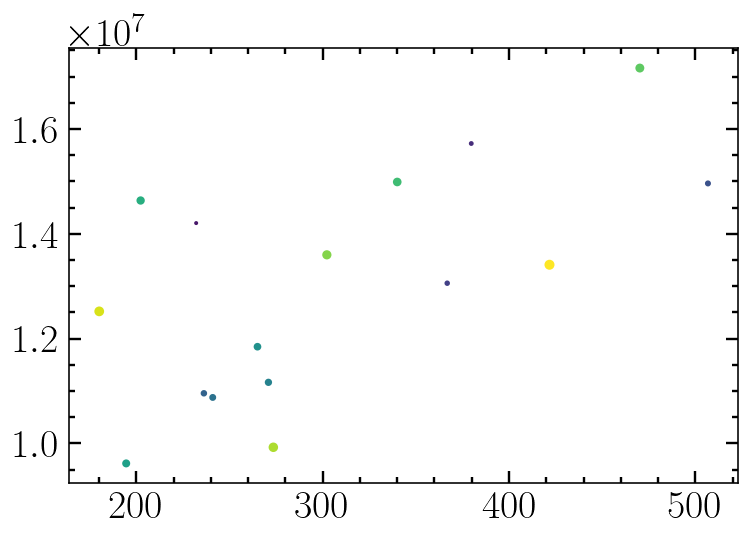

In [29]:
plt.scatter(sig,tc,c=t,s=t)


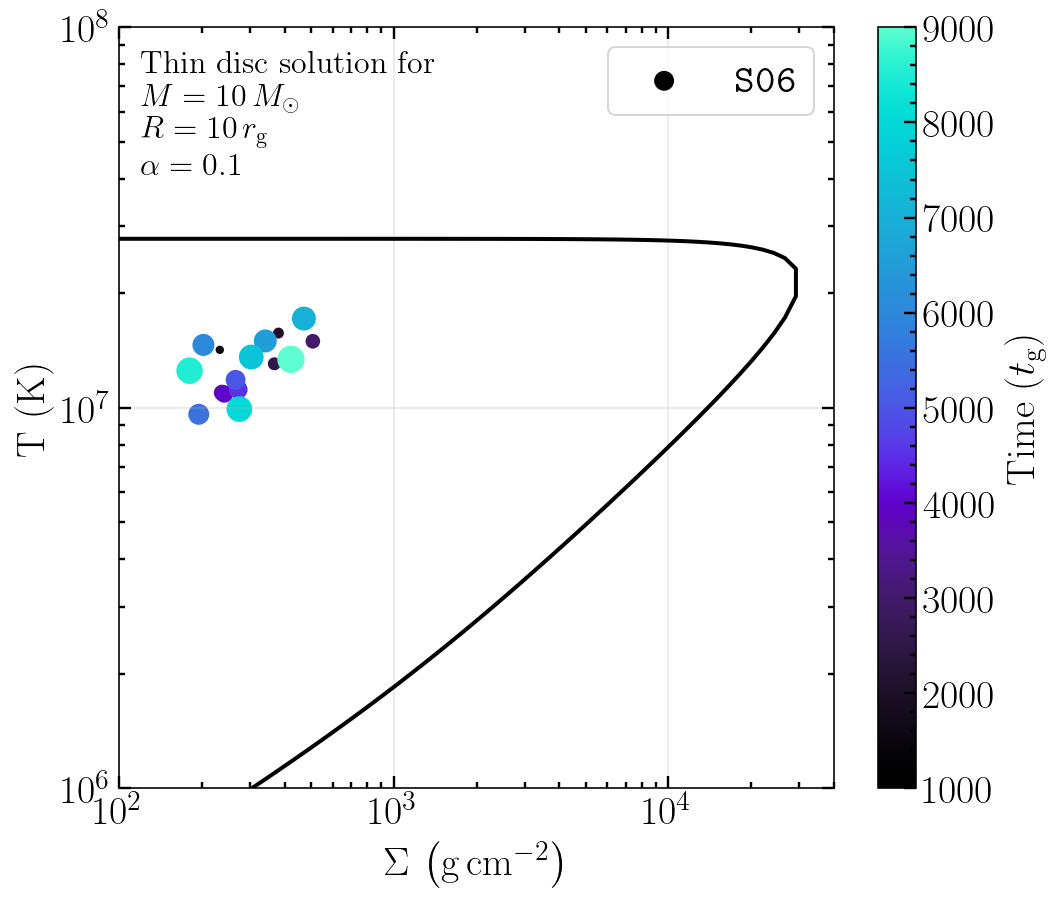

In [45]:
sig_min = 1e2
sig_max = 4e4
sig_an = np.linspace(sig_min,sig_max,100)

sigma_all = np.concatenate([sigmas, sigmas[::-1]])
T_all     = np.concatenate([T_solutions_1,T_solutions_2[::-1]])

mask = ~np.isnan(sigma_all) & ~np.isnan(T_all)
sigma_all = sigma_all[mask]
T_all = T_all[mask]

# Create array with same length as Sigmas, starting from 1000 and increasing by 500
time_array = np.arange(1000, 1000 + 500 * len(Sigmas), 500)
sigmas_middle = sig_eq_mid(Ts, R, m, alpha)

plt.figure(figsize=(8, 7))

plt.plot(sigma_all, T_all, color='black',lw = 2)


plt.ylabel(r'T (K)')
plt.xlabel(r'$\Sigma\, \left(\rm g\, cm^{-2}\right)$')


cm = plt.cm.get_cmap('cmr.cosmic')

sc = plt.scatter(sig, tc, c=time_array, s=t*10, cmap=cm, label=r'\texttt{S06}')
cbar = plt.colorbar(sc)
cbar.set_label(r'Time $\left(t_\mathrm{g}\right)$')

plt.xscale('log')
plt.yscale('log')

plt.ylim(1e6,1e8)
plt.xlim(sig_min, sig_max)

plt.yscale('log')
plt.xscale('log')
plt.grid(True, alpha=0.3)

# plt.axhline(T_inner(alpha, m, R), color='red', linestyle='--')
# plt.loglog(sigmas_middle,Ts, color='green', linestyle='--', label='T middle solution')

plt.legend()

plt.text(
    0.03, 0.97,
    f"Thin disc solution for\n$M={m}\,M_\odot$\n$R={R}\,r_\mathrm{{g}}$\n$\\alpha={alpha}$",
    transform=plt.gca().transAxes,
    fontsize=16,
    verticalalignment='top',
)
plt.savefig('sigma_T_puffy.pdf',bbox_inches='tight')
plt.show()

In [51]:
## Time evolution S09

folder = os.fsencode(path + 'simdata/2Dfiles_s09/')
files = []

for file in os.listdir(folder):
    filename = os.fsdecode(file)
    if filename.endswith( ('.dat') ):
        files.append(filename)

files.sort()


print(files)
datas =[]
for i in range (0,len(files)):
    datas.append(simext2d.simext2d(path + 'simdata/2Dfiles_s09/' + files[i]))

['simphiavgext0700.dat', 'simphiavgext0800.dat', 'simphiavgext0808.dat', 'simphiavgext0816.dat', 'simphiavgext0824.dat', 'simphiavgext0832.dat', 'simphiavgext0840.dat', 'simphiavgext0848.dat', 'simphiavgext0856.dat', 'simphiavgext0864.dat', 'simphiavgext0872.dat', 'simphiavgext0880.dat', 'simphiavgext0888.dat', 'simphiavgext0896.dat', 'simphiavgext0904.dat', 'simphiavgext0912.dat', 'simphiavgext0920.dat', 'simphiavgext0928.dat', 'simphiavgext0936.dat', 'simphiavgext0944.dat', 'simphiavgext0952.dat', 'simphiavgext0960.dat', 'simphiavgext0968.dat', 'simphiavgext0976.dat', 'simphiavgext0984.dat', 'simphiavgext0992.dat', 'simphiavgext1000.dat']


In [52]:
## Interpolate to xz grid

#define xz grid with n steps
n = 1000
xx = np.linspace(0,100,n)
zz = np.linspace(0,100,n)

x_grid, z_grid = np.meshgrid(xx,zz,indexing='ij')

x_line = datas[0].r*np.sin(datas[0].th)
z_line = datas[0].r*np.cos(datas[0].th)

datas[0].x_grid = x_grid
datas[0].z_grid = z_grid

rhos = []
tems = []
for i in range (0,len(datas)):
    foo = datas[i].rho
    bar = tempscale*datas[i].uint/foo
    rhos.append(griddata((x_line,z_line),foo,(x_grid,z_grid)))
    tems.append(griddata((x_line,z_line),bar,(x_grid,z_grid))) 
    print(f"Processed file {files[i]}")
    

Sigmas09 = []
Tcs09 = []
sigmascale = 6.172971e+15*1.477000e+06
for i in range (0,len(rhos)):
    foo = np.trapz(rhos[i],z_grid,axis = 1)
    Sigmas09.append(foo*sigmascale)
    bar = tems[i]
    Tcs09.append(bar[:,0]) 

Processed file simphiavgext0700.dat
Processed file simphiavgext0800.dat
Processed file simphiavgext0808.dat
Processed file simphiavgext0816.dat
Processed file simphiavgext0824.dat
Processed file simphiavgext0832.dat
Processed file simphiavgext0840.dat
Processed file simphiavgext0848.dat
Processed file simphiavgext0856.dat
Processed file simphiavgext0864.dat
Processed file simphiavgext0872.dat
Processed file simphiavgext0880.dat
Processed file simphiavgext0888.dat
Processed file simphiavgext0896.dat
Processed file simphiavgext0904.dat
Processed file simphiavgext0912.dat
Processed file simphiavgext0920.dat
Processed file simphiavgext0928.dat
Processed file simphiavgext0936.dat
Processed file simphiavgext0944.dat
Processed file simphiavgext0952.dat
Processed file simphiavgext0960.dat
Processed file simphiavgext0968.dat
Processed file simphiavgext0976.dat
Processed file simphiavgext0984.dat
Processed file simphiavgext0992.dat
Processed file simphiavgext1000.dat


In [53]:
t09 = np.arange(len(Sigmas09))

sig09 = []
tc09 = []
for i in range (0, len(Sigmas09)):
    foo = Sigmas09[i]
    bar = Tcs09[i]
    sig09.append(foo[100])
    tc09.append(bar[100])
    

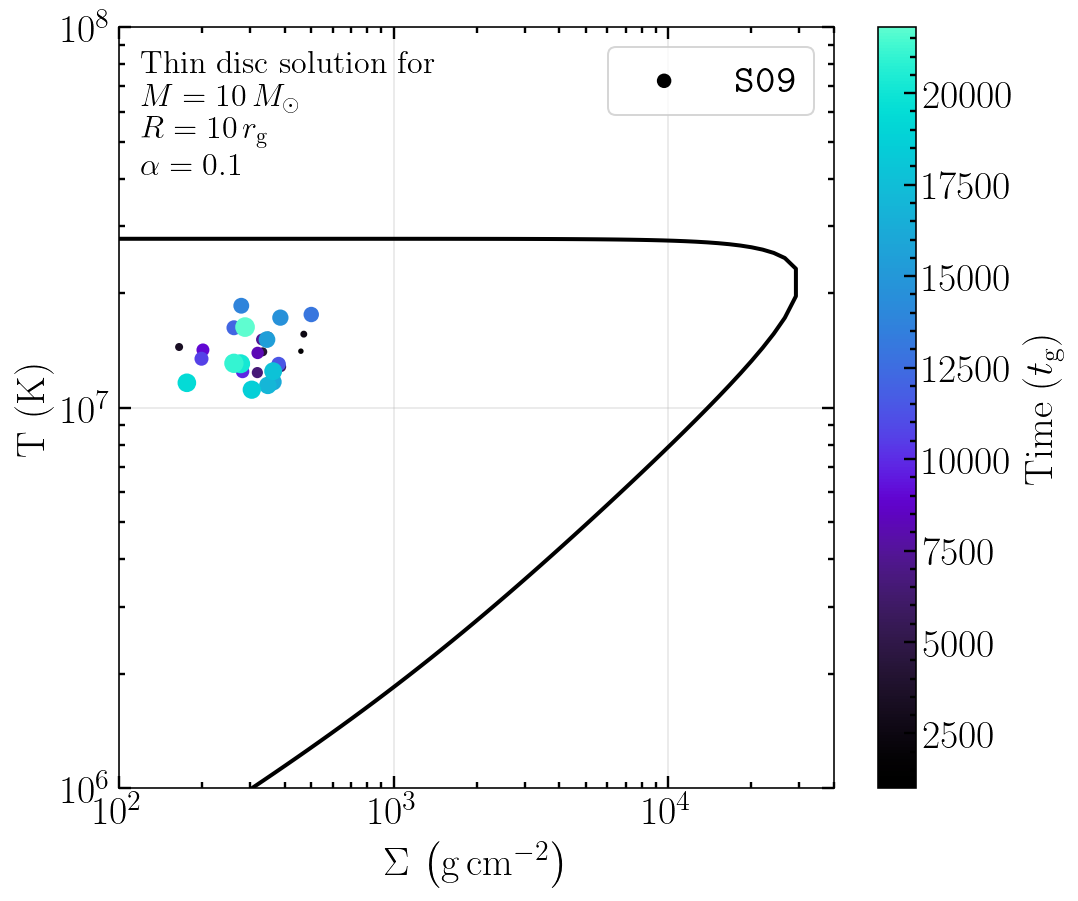

In [57]:
sig_min = 1e2
sig_max = 4e4
sig_an = np.linspace(sig_min,sig_max,100)

sigma_all = np.concatenate([sigmas, sigmas[::-1]])
T_all     = np.concatenate([T_solutions_1,T_solutions_2[::-1]])

mask = ~np.isnan(sigma_all) & ~np.isnan(T_all)
sigma_all = sigma_all[mask]
T_all = T_all[mask]

# Create array with same length as Sigmas, starting from 1000 and increasing by 500
time_array09 = np.arange(1000, 1000 + 800 * len(Sigmas09), 800)

plt.figure(figsize=(8, 7))

plt.plot(sigma_all, T_all, color='black',lw = 2)


plt.ylabel(r'T (K)')
plt.xlabel(r'$\Sigma\, \left(\rm g\, cm^{-2}\right)$')


cm = plt.cm.get_cmap('cmr.cosmic')

sc = plt.scatter(sig09, tc09, c=time_array09, s=t09*3, cmap=cm, label=r'\texttt{S09}')
cbar = plt.colorbar(sc)
cbar.set_label(r'Time $\left(t_\mathrm{g}\right)$')

plt.xscale('log')
plt.yscale('log')

plt.ylim(1e6,1e8)
plt.xlim(sig_min, sig_max)

plt.yscale('log')
plt.xscale('log')
plt.grid(True, alpha=0.3)

# plt.axhline(T_inner(alpha, m, R), color='red', linestyle='--')
# plt.loglog(sigmas_middle,Ts, color='green', linestyle='--', label='T middle solution')

plt.legend()

plt.text(
    0.03, 0.97,
    f"Thin disc solution for\n$M={m}\,M_\odot$\n$R={R}\,r_\mathrm{{g}}$\n$\\alpha={alpha}$",
    transform=plt.gca().transAxes,
    fontsize=16,
    verticalalignment='top',
)
# plt.savefig('sigma_T_puffy.pdf',bbox_inches='tight')
plt.show()